# Temporal Point Processes — Homogeneous and Inhomogeneous Poisson

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/point_processes_temporal.ipynb)

xtremax ships temporal point processes in three layers: pure-JAX *primitives*, `equinox.Module` *operators*, and NumPyro *distributions*. This notebook walks through all three for the two workhorse processes in the current release — the Homogeneous Poisson Process (HPP) and the Inhomogeneous Poisson Process (IPP) — with three intensity flavours: constant, piecewise-constant, and sinusoidal.

**What you'll learn:**

1. How to sample and fit an HPP via the operator API.
2. How to build an IPP from a closed-form intensity or a piecewise-constant schedule.
3. How to use the time-rescaling residuals, KS statistic, and QQ plot to check model fit.
4. How the operators integrate with `optax` for maximum-likelihood fitting of parameterised intensities.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import random

from xtremax.point_processes.operators import (
    HomogeneousPoissonProcess,
    InhomogeneousPoissonProcess,
)


jax.config.update("jax_enable_x64", False)
plt.rcParams["figure.figsize"] = (8.0, 4.0)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Homogeneous Poisson Process

Constant intensity $\lambda$ on $[0, T]$. The count $N \sim \mathrm{Poisson}(\lambda T)$ and event times are i.i.d. uniform given the count.

In [2]:
hpp = HomogeneousPoissonProcess(rate=2.0, observation_window=10.0)

key = random.PRNGKey(0)
times, mask, n_events = hpp.sample(key, max_events=64)

print(
    f"Sampled n_events = {int(n_events)} (expected λT = {hpp.rate * hpp.observation_window:.1f})"
)
print(f"First five event times: {times[mask][:5]}")

Sampled n_events = 13 (expected λT = 20.0)
First five event times: [0.0729382  0.2089119  0.950073   0.96612096 1.1928833 ]


Visualise a single realisation as a tick plot plus the cumulative count vs the expected $\lambda t$.

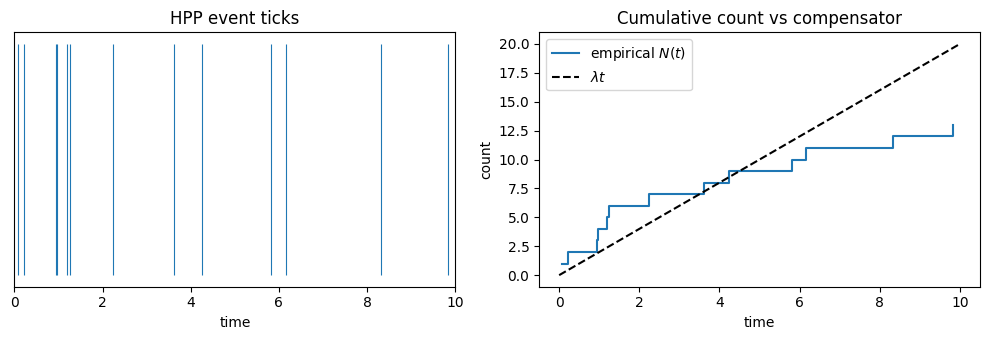

In [3]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.5))

real_times = np.asarray(times[mask])
ax0.vlines(real_times, 0, 1, color="C0", linewidth=0.8)
ax0.set_xlim(0, float(hpp.observation_window))
ax0.set_yticks([])
ax0.set_xlabel("time")
ax0.set_title("HPP event ticks")

counts = np.arange(1, len(real_times) + 1)
ax1.step(real_times, counts, where="post", label="empirical $N(t)$")
grid = np.linspace(0, float(hpp.observation_window), 100)
ax1.plot(grid, float(hpp.rate) * grid, "--", color="k", label=r"$\lambda t$")
ax1.legend()
ax1.set_xlabel("time")
ax1.set_ylabel("count")
ax1.set_title("Cumulative count vs compensator")

plt.tight_layout()
plt.show()

### Goodness-of-fit — time-rescaling theorem

Under the null, $\tau_i = \Lambda(t_i) - \Lambda(t_{i-1})$ are i.i.d. $\mathrm{Exp}(1)$. The operator bundles residuals, KS statistic, and QQ-plot data into a single call.

KS statistic: 0.178


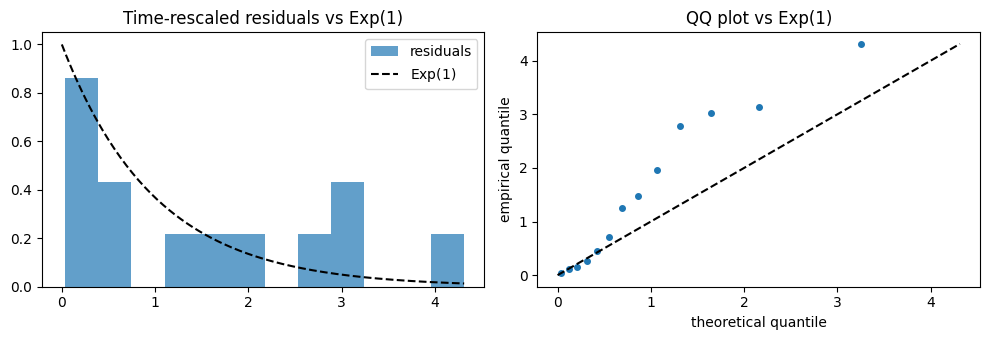

In [4]:
gof = hpp.goodness_of_fit(times, mask)
print(f"KS statistic: {float(gof.ks_statistic):.3f}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.5))

# Histogram of residuals versus Exp(1) pdf.
res = np.asarray(gof.residuals[gof.mask])
ax0.hist(res, bins=12, density=True, alpha=0.7, color="C0", label="residuals")
x = np.linspace(0, res.max(), 200)
ax0.plot(x, np.exp(-x), "k--", label=r"$\mathrm{Exp}(1)$")
ax0.legend()
ax0.set_title("Time-rescaled residuals vs Exp(1)")

# QQ plot.
theoretical = np.asarray(gof.theoretical_quantiles)
empirical = np.asarray(gof.empirical_quantiles)
good = ~np.isnan(theoretical)
ax1.plot(theoretical[good], empirical[good], "o", color="C0", markersize=4)
lim = max(theoretical[good].max(), empirical[good].max())
ax1.plot([0, lim], [0, lim], "k--")
ax1.set_xlabel("theoretical quantile")
ax1.set_ylabel("empirical quantile")
ax1.set_title("QQ plot vs Exp(1)")

plt.tight_layout()
plt.show()

## 2. Inhomogeneous Poisson Process — piecewise-constant intensity

A useful workhorse when events come from binned rate schedules (e.g. hourly counts, seasonal blocks). The factory constructor computes the exact $\Lambda(T)$ and $\lambda_\max$ for you.

In [5]:
bin_edges = jnp.array([0.0, 4.0, 8.0, 12.0, 24.0])
rates = jnp.array([1.0, 3.0, 5.0, 2.0])

ipp_pw = InhomogeneousPoissonProcess.from_piecewise_constant(
    bin_edges=bin_edges,
    rates=rates,
    n_integration_points=400,
)

assert ipp_pw.integrated_intensity is not None
assert ipp_pw.lambda_max is not None
print(f"Λ(T)     = {float(ipp_pw.integrated_intensity):.2f}")
print(f"λ_max    = {float(ipp_pw.lambda_max):.2f}")

Λ(T)     = 60.00
λ_max    = 5.00


Accepted 75 events out of 133 candidates


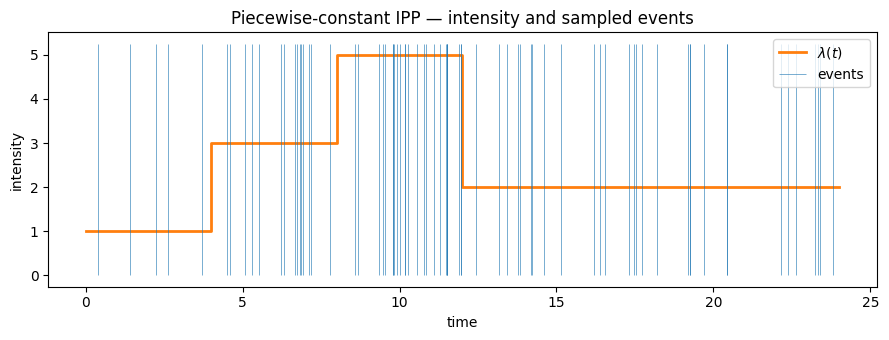

In [6]:
times_pw, mask_pw, n_cand = ipp_pw.sample(random.PRNGKey(7), max_candidates=512)
n_accepted = int(mask_pw.sum())
print(f"Accepted {n_accepted} events out of {int(n_cand)} candidates")

fig, ax = plt.subplots(figsize=(9, 3.5))
t_grid = np.linspace(0, float(bin_edges[-1]), 400)
ax.step(
    np.asarray(bin_edges),
    np.concatenate([np.asarray(rates), np.asarray(rates[-1:])]),
    where="post",
    color="C1",
    label=r"$\lambda(t)$",
    linewidth=2,
)
ax.vlines(
    np.asarray(times_pw[mask_pw]),
    0,
    float(rates.max()) * 1.05,
    color="C0",
    linewidth=0.6,
    alpha=0.7,
    label="events",
)
ax.set_xlabel("time")
ax.set_ylabel("intensity")
ax.set_title("Piecewise-constant IPP — intensity and sampled events")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Inhomogeneous Poisson Process — sinusoidal (diurnal) intensity

$\lambda(t) = 5 + 3 \sin(2\pi t / 24)$ on a 48-hour window. We provide a closed-form upper bound $\lambda_\max = 8$ and let the operator compute $\Lambda(T)$ via quadrature.

Numerical Λ(T=48) ≈ 240.00 (analytic = 240 since ∫sin = 0)


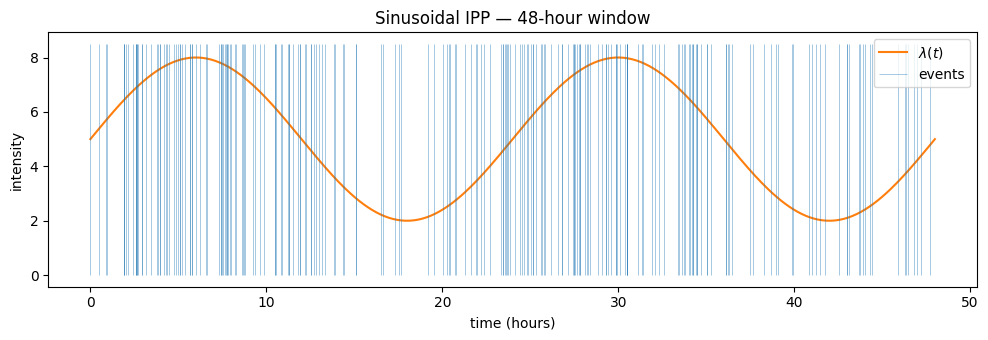

In [7]:
def log_intensity_sine(t):
    return jnp.log(5.0 + 3.0 * jnp.sin(2 * jnp.pi * t / 24.0))


ipp_sine = InhomogeneousPoissonProcess(
    log_intensity_fn=log_intensity_sine,
    observation_window=jnp.asarray(48.0),
    lambda_max=jnp.asarray(8.0),
    n_integration_points=400,
)

Lambda_T = ipp_sine.cumulative_intensity(jnp.asarray(48.0))
print(f"Numerical Λ(T=48) ≈ {float(Lambda_T):.2f} (analytic = 240 since ∫sin = 0)")

times_s, mask_s, _ = ipp_sine.sample(random.PRNGKey(11), max_candidates=1024)

fig, ax = plt.subplots(figsize=(10, 3.5))
t_grid = np.linspace(0, 48.0, 400)
ax.plot(
    t_grid,
    np.exp(np.asarray(log_intensity_sine(jnp.asarray(t_grid)))),
    color="C1",
    label=r"$\lambda(t)$",
)
ax.vlines(
    np.asarray(times_s[mask_s]),
    0,
    8.5,
    color="C0",
    linewidth=0.4,
    alpha=0.7,
    label="events",
)
ax.set_xlabel("time (hours)")
ax.set_ylabel("intensity")
ax.set_title("Sinusoidal IPP — 48-hour window")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Maximum-likelihood fit of a parameterised intensity

All operators are valid PyTrees, so `jax.grad` (via `equinox.filter_grad`) flows through them. Here we fit a constant intensity by plain gradient descent — trivial, but it shows the pattern you'd use for any neural intensity.

True rate: 3.5, fitted: 3.500


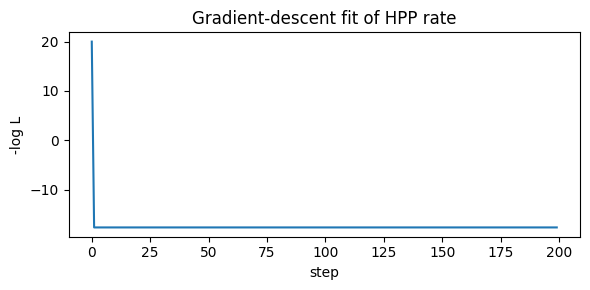

In [8]:
# Generate "observed" data from a known HPP.
true_rate = 3.5
data_hpp = HomogeneousPoissonProcess(rate=true_rate, observation_window=20.0)
key, key_data = random.split(random.PRNGKey(0))
times_obs, mask_obs, n_obs = data_hpp.sample(key_data, max_events=256)

# Start from a bad initial guess.
model = HomogeneousPoissonProcess(
    rate=jnp.asarray(1.0), observation_window=jnp.asarray(20.0)
)


def neg_log_lik(model, n_obs):
    return -model.log_prob(n_obs)


@jax.jit
def update(model, n_obs, lr=0.05):
    loss, grads = eqx.filter_value_and_grad(neg_log_lik)(model, n_obs)
    new_model = eqx.tree_at(lambda m: m.rate, model, model.rate - lr * grads.rate)
    return new_model, loss


losses = []
for _ in range(200):
    model, loss = update(model, n_obs)
    losses.append(float(loss))

print(f"True rate: {true_rate}, fitted: {float(model.rate):.3f}")

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("step")
plt.ylabel("-log L")
plt.title("Gradient-descent fit of HPP rate")
plt.tight_layout()
plt.show()

## 5. Where to next

* The `xtremax.point_processes.distributions` module wraps these operators as NumPyro `Distribution` subclasses — drop-in use inside `numpyro.sample` / MCMC / SVI models.
* The `xtremax.point_processes.primitives` module exposes the same computations as pure functions, ready for `jax.jit` / `jax.vmap` / `jax.grad` without ever touching a class.
* Future releases will add spatial, marked, self-exciting (Hawkes), and renewal processes in the same three-layer style.